In [67]:
from datetime import datetime
import requests

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf
import pygad

# Toy example

In [6]:
prices = dict()
prices['A'] = np.array([1,0.5,1,1.5] * 20)
prices['B'] = np.ones_like(prices['A'])
print(prices)

{'A': array([1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. ,
       0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5,
       1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. ,
       1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5,
       1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. ,
       0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5,
       1. , 1.5]), 'B': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])}


In [8]:
returns = np.array([p[1:] / p[:-1] for s, p in prices.items()]).T
w = np.ones(2) / 2
np.cumprod(returns @ w)

array([ 0.75      ,  1.125     ,  1.40625   ,  1.171875  ,  0.87890625,
        1.31835938,  1.64794922,  1.37329102,  1.02996826,  1.54495239,
        1.93119049,  1.60932541,  1.20699406,  1.81049109,  2.26311386,
        1.88592821,  1.41444616,  2.12166924,  2.65208655,  2.21007213,
        1.65755409,  2.48633114,  3.10791393,  2.58992827,  1.9424462 ,
        2.91366931,  3.64208663,  3.03507219,  2.27630415,  3.41445622,
        4.26807027,  3.55672523,  2.66754392,  4.00131588,  5.00164485,
        4.16803738,  3.12602803,  4.68904205,  5.86130256,  4.8844188 ,
        3.6633141 ,  5.49497115,  6.86871394,  5.72392828,  4.29294621,
        6.43941932,  8.04927414,  6.70772845,  5.03079634,  7.54619451,
        9.43274314,  7.86061928,  5.89546446,  8.84319669, 11.05399586,
        9.21166322,  6.90874742, 10.36312112, 12.9539014 , 10.79491784,
        8.09618838, 12.14428257, 15.18035321, 12.65029434,  9.48772075,
       14.23158113, 17.78947641, 14.82456368, 11.11842276, 16.67

# Real stock data

In [11]:
start_date = '2010-01-01'
end_train_date = '2024-12-31'
end_test_date = '2025-12-31'

In [ ]:
sp_ticker = '^GSPC'

sp_data_raw = yf.download(sp_ticker, start=start_date, end=end_test_date)

In [16]:
def get_sp500_tickers_by_date(target_date_str):
    """
    Returns the list of S&P 500 tickers active on a specific date.
    :param target_date_str: Date string in 'YYYY-MM-DD' format.
    """
    target_date = pd.to_datetime(target_date_str)

    # 1. Scraping current constituents and historical changes from Wikipedia
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    tables = pd.read_html(response.text)


    # Table 0: Current Constituents
    df_current = tables[0]
    # Table 1: Selected Changes (Additions/Deletions)
    df_changes = tables[1]

    # 2. Process current tickers into a set
    current_tickers = set(df_current['Symbol'].tolist())

    # 3. Clean and process the changes table
    # Wikipedia's changes table has multi-index headers; we simplify them
    df_changes = df_changes.copy()
    # Handle the date column and filter out changes that happened AFTER our target date
    # We work backwards from today to the target date
    df_changes['Date'] = pd.to_datetime(df_changes['Effective Date']['Effective Date'], errors='coerce')

    # Get all changes that happened between target_date and today
    relevant_changes = df_changes[df_changes['Date'] > target_date]

    # 4. Reverse the changes
    # If a ticker was ADDED after our target date, it shouldn't be in our historical list.
    # If a ticker was REMOVED after our target date, it SHOULD be in our historical list.
    for _, row in relevant_changes.iterrows():
        added_ticker = row['Added']['Ticker']
        removed_ticker = row['Removed']['Ticker']

        if pd.notna(added_ticker):
            if added_ticker in current_tickers:
                current_tickers.remove(added_ticker)

        if pd.notna(removed_ticker):
            current_tickers.add(removed_ticker)

    return sorted(list(current_tickers))


tickers = get_sp500_tickers_by_date(end_train_date)

In [24]:
df_raw = yf.download(tickers, start_date, end_test_date)

[                       1%                       ]  6 of 503 completed$BRK.B: possibly delisted; no timezone found
[*****                 10%                       ]  49 of 503 completed$IPG: possibly delisted; no timezone found
[*****                 10%                       ]  50 of 503 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}
[*****                 10%                       ]  52 of 503 completed$K: possibly delisted; no timezone found
[*****                 11%                       ]  56 of 503 completed$HES: possibly delisted; no timezone found
[********************  42%                       ]  210 of 503 completed$JNPR: possibly delisted; no timezone found
[**********************56%**                     ]  280 of 503 completed$WBA: possibly delisted; no timezone found
[**********************68%********               ]  343 of 503 completed$DFS: possibly delisted; no timezone found
[***

In [26]:
df = df_raw['Close']
df = df[df.notna().all(axis=0)[lambda s: s].index]
df = (1 + df.pct_change()).fillna(1)
df

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2010-01-05,0.989137,1.001729,0.991921,0.996664,1.006181,1.016446,0.998421,1.005402,0.994630,0.984807,...,0.996328,0.987331,0.997759,1.021228,1.060819,0.988140,1.003904,0.996580,1.031656,0.998256
2010-01-06,0.996447,0.984094,1.005553,0.995677,1.010630,0.997878,0.998102,0.997471,0.997653,1.002373,...,1.002047,0.990250,1.016099,0.988943,0.986883,1.001920,1.008643,0.992851,0.999677,0.992313
2010-01-07,0.998703,0.998151,1.008284,0.994118,0.999065,0.980595,0.992078,0.989544,0.999530,1.005525,...,1.004086,1.003109,0.997053,0.995527,1.021356,0.995687,0.996858,0.999712,1.022941,0.975000
2010-01-08,0.999676,1.006648,1.005112,0.998028,0.996022,0.994578,1.005750,0.987512,0.998587,1.030612,...,0.999186,0.999742,0.998892,0.990791,0.992835,1.000481,0.995989,1.000288,0.978995,0.996750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.998845,1.005130,0.994728,0.998353,1.000369,0.985708,1.003299,0.993431,0.989490,0.990382,...,1.000143,1.009458,0.999699,0.993252,0.991903,1.002167,1.010749,0.995234,0.995880,0.989494
2025-12-24,0.999711,1.005324,1.002168,0.994224,0.997082,1.001589,1.002999,1.005394,1.004241,1.002117,...,1.005838,0.997009,1.006681,1.008917,1.000480,1.001081,0.998325,0.998641,1.008946,0.996515
2025-12-26,1.000506,0.998503,1.000240,0.994502,1.004111,1.002323,0.997406,1.002250,1.002867,1.008383,...,0.999009,0.991470,1.000239,0.999158,0.994721,1.004454,0.999077,0.993002,1.005985,1.001505


In [40]:
df_train = df[df.index <= end_train_date]
df_test = df[df.index > end_train_date]

df_train.shape, df_test.shape

((3774, 422), (249, 422))

# Stock selection

In [43]:
num_stocks = 10

corr_mat = df_train.corr().abs()

selected_stocks = set([df_train.cumprod().iloc[-1].idxmax()])

remaining_stocks = set(df_train.columns) - selected_stocks

for _ in range(num_stocks - 1):
  curr_corr_mat = corr_mat.loc[list(selected_stocks), list(remaining_stocks)]
  max_curr_corr_mat = curr_corr_mat.max(axis=0)

  selected_stock = max_curr_corr_mat.idxmin()
  selected_stocks.add(selected_stock)
  remaining_stocks.remove(selected_stock)

selected_stocks

{'CPB', 'DLTR', 'GILD', 'HUM', 'NEM', 'NVDA', 'PCG', 'SW', 'TPL', 'WBD'}

In [44]:
df_stocks = df_train[list(selected_stocks)]
df_stocks

Ticker,CPB,NVDA,PCG,WBD,HUM,SW,DLTR,GILD,TPL,NEM
Date,,,,,,,,,,
2010-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2010-01-05,1.001771,1.014603,0.988764,1.039355,0.999562,1.000000,0.987336,0.999076,1.056642,1.002684
2010-01-06,0.988801,1.006396,1.011591,1.014898,1.007008,1.000000,1.058663,1.034674,0.974659,1.021202
2010-01-07,0.984799,0.980402,0.982925,0.999388,1.046542,1.000000,0.993446,1.002458,0.991667,0.993550
2010-01-08,0.993644,1.002161,1.000915,1.003060,0.987324,1.000000,0.986206,0.992645,0.974789,1.006695
...,...,...,...,...,...,...,...,...,...,...
2024-12-24,1.005311,1.003938,1.011506,1.010536,0.999140,1.011125,0.995253,1.005889,1.019088,1.003931
2024-12-26,1.001921,0.997932,0.999505,1.006635,1.002427,0.993031,1.038294,1.004896,1.005003,0.994257
2024-12-27,1.002157,0.979132,0.996536,0.999058,0.998048,1.003693,0.997375,0.996822,0.981243,0.993437


# Portfolio optimization

In [75]:
def sharpe_ratio(x, solution, y):
    weights = solution / solution.sum()
    
    returns = df_stocks @ weights
    mu = returns.mean()
    std = returns.std()
    
    return ((mu - 1) / std) * np.sqrt(252)


def return_fitness(ga_instance, solution, solution_idx):
    weights = solution / solution.sum()

    portfolio_returns = df_stocks @ weights
    mu = portfolio_returns.mean()
    annualized_return = mu * 252
    
    return annualized_return

In [77]:
ga_instance = pygad.GA(
    num_generations=100,
    num_parents_mating=10,
    fitness_func=return_fitness,
    sol_per_pop=100,
    num_genes=len(df_stocks.columns),
    init_range_low=0,
    init_range_high=1,
    gene_space={'low': 0, 'high':1},
    random_seed=1
)

In [79]:
ga_instance.run()

In [81]:
solution, best_score, _ = ga_instance.best_solution()

In [83]:
weights = solution / solution.sum()
weights

array([0.00177907, 0.97607835, 0.00408236, 0.00253807, 0.00349389,
       0.003977  , 0.00249968, 0.00259392, 0.00159675, 0.00136091])

/Users/omerkoren/dev/stocks_analysis/stocks_analysis_venv/lib/python3.12/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


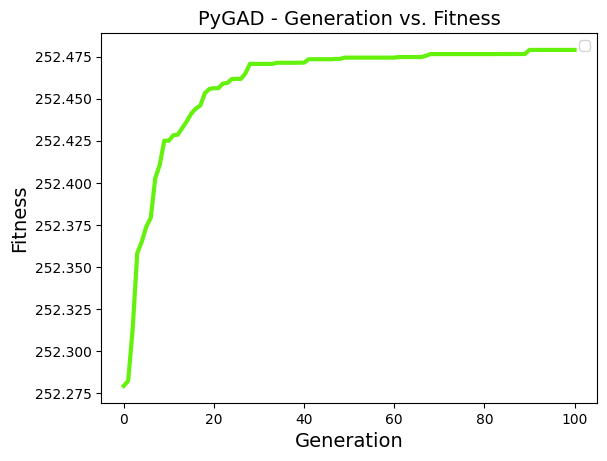

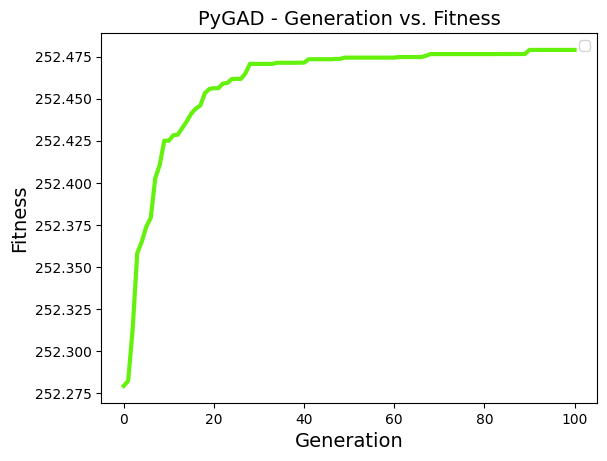

In [89]:
ga_instance.plot_fitness()

In [91]:
scores = [
    sharpe_ratio(None, np.random.dirichlet([1] * len(df_stocks.columns)), None)
    for _ in range(1000)
]

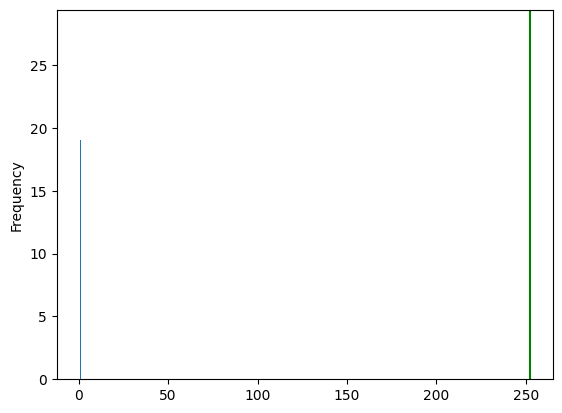

In [93]:
pd.Series(scores).plot.hist(bins=100)
plt.axvline(best_score, color='green')

# Optimized portfolio vs. baselines

In [96]:
df_test_selected = df_test[list(selected_stocks)]

df_test_selected.shape

(249, 10)

In [98]:
(df_test_selected @ weights).cumprod()

Date
2025-01-02    1.029382
2025-01-03    1.074135
2025-01-06    1.110259
2025-01-07    1.042727
2025-01-08    1.042115
                ...   
2025-12-23    1.407614
2025-12-24    1.403376
2025-12-26    1.417342
2025-12-29    1.400582
2025-12-30    1.395700
Length: 249, dtype: float64

[*********************100%***********************]  1 of 1 completed


In [102]:
sp_data = sp_data_raw.copy()
sp_data = sp_data['Close']

sp_data.columns=['SP']
print(sp_data.iloc[-1]['SP'] / sp_data.iloc[0]['SP'])

1.1725049640623306


In [104]:
uniform_weights = [1 / len(selected_stocks)] * len(selected_stocks)

(df_test_selected @ uniform_weights).cumprod()

Date
2025-01-02    1.014706
2025-01-03    1.018457
2025-01-06    1.026257
2025-01-07    1.015654
2025-01-08    1.003962
                ...   
2025-12-23    1.320533
2025-12-24    1.324483
2025-12-26    1.325062
2025-12-29    1.320746
2025-12-30    1.322337
Length: 249, dtype: float64